Outliers

comments
Outliers can skew our data, distort statistical analysis, and affect machine learning models. Identifying and handling outliers is a crucial step in data preprocessing and exploratory data analysis (EDA).

What is an Outlier?
An outlier is an observation in a dataset that is significantly different from the rest of the values. It lies far away from the normal data distribution.

Example:

If we measure body temperature, most values will be around 98.6°F. But if one recorded value is 888°F, it is an outlier and most likely a data entry error.
If we measure the weight of high school students, values between 40-80 kg are expected. But a recorded weight of 1234 kg is an outlier.
Why Do Outliers Occur?
Outliers can occur due to several reasons:

Data Entry Errors:

Typing mistakes, misplaced decimal points (e.g., 888°F instead of 98.8°F).
Natural Variability in Data:

Some people naturally have extremely high or low values in certain measurements.
Measurement Errors:

Faulty sensors, incorrect equipment calibration, or improper data recording.
Unexpected Events:

Stock market crashes, anomalies in credit card transactions (fraud detection).

In [11]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [5]:
data = pd.read_csv("scholarship.csv")

In [6]:
df = data.copy()

In [7]:
df.head()

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0


In [8]:
df.shape

(1000, 3)

### to know the distribution of data

C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2071929939.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['semester_percentage'])
C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2071929939.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['scholarship_exam_marks'])


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

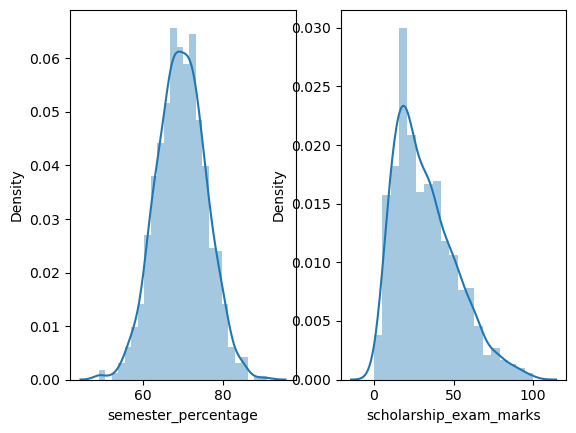

In [13]:
plt.subplot(1,2,1)
sns.distplot(df['semester_percentage'])
plt.subplot(1,2,2)
sns.distplot(df['scholarship_exam_marks'])

### semester_percentage folows normal distribution

In [16]:
mean = df['semester_percentage'].mean()
print(mean)
sd = df['semester_percentage'].std()
print(sd)

69.6124
6.158978751323897


In [18]:
high = mean + 3*sd
low = mean - 3*sd
print(high,",",low)

88.08933625397168 , 51.13546374602831


### values which are not in range of high and low are considered as outliers

In [20]:
outliers = df[(df['semester_percentage']> high) | (df['semester_percentage']<low)]
print(outliers)

     semester_percentage  scholarship_exam_marks  got_scholarship
485                 49.2                      44                1
995                 88.7                      44                1
996                 91.2                      65                1
997                 48.9                      34                0
999                 49.0                      10                1


### trimed dataset(removed outliers)

In [22]:
removed_dataset = df[(df['semester_percentage']< high) & (df['semester_percentage']>low)]
print(removed_dataset)

     semester_percentage  scholarship_exam_marks  got_scholarship
0                   71.9                      26                1
1                   74.6                      38                1
2                   75.4                      40                1
3                   64.2                       8                1
4                   72.3                      17                0
..                   ...                     ...              ...
991                 70.4                      57                0
992                 62.6                      12                0
993                 67.3                      21                1
994                 64.8                      63                0
998                 86.2                      46                1

[995 rows x 3 columns]


## handle Outliers using z-score
### ->find the z-score for all the values in dataset using formula
### ->similar to 3sd we need to remove the data which has z-score more than 3 and less than -1

In [24]:
df['z-score'] = (df['semester_percentage']-df['semester_percentage'].mean())/df['semester_percentage'].std()

In [25]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
998,86.2,46,1,2.693239


### outliers using z-score

In [28]:
df[(df['z-score']>3) | (df['z-score']<-3)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
485,49.2,44,1,-3.314251
995,88.7,44,1,3.099150
996,91.2,65,1,3.505062
997,48.9,34,0,-3.362960
999,49.0,10,1,-3.346724


### removing outliers

In [59]:
newdata=df[(df['z-score']<3) & (df['z-score']>-3)]
newdata

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
0,71.9,26,1,0.371425
1,74.6,38,1,0.809810
2,75.4,40,1,0.939701
3,64.2,8,1,-0.878782
4,72.3,17,0,0.436371
...,...,...,...,...
991,70.4,57,0,0.127878
992,62.6,12,0,-1.138565
993,67.3,21,1,-0.375452
994,64.8,63,0,-0.781363


### we can observe similar values which are occured using 3sd method

# Capping
## if you had larger no of outliers use capping 
## if you had less no. of outliers you can Trimm them
#### if we are getting less values than lower limit we will replace them with some values or lowerlimit values
#### if we are getting greater than upperlimit we will replace them with some value or upper value

In [34]:
upperlimit = mean + 3*sd
lowerlimit = mean - 3*sd
print(upperlimit,",",lowerlimit)

88.08933625397168 , 51.13546374602831


In [35]:
df['semester_percentage'] = np.where(df['semester_percentage']> upperlimit,upperlimit,
                                     np.where(df['semester_percentage']< lowerlimit,lowerlimit,df['semester_percentage']))

In [36]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
0,71.900000,26,1,0.371425
1,74.600000,38,1,0.809810
2,75.400000,40,1,0.939701
3,64.200000,8,1,-0.878782
4,72.300000,17,0,0.436371
...,...,...,...,...
995,88.089336,44,1,3.099150
996,88.089336,65,1,3.505062
997,51.135464,34,0,-3.362960
998,86.200000,46,1,2.693239


#### we can observe here we got 1000rows which means we have capped the outlier values

In [36]:
df

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score
0,71.900000,26,1,0.371425
1,74.600000,38,1,0.809810
2,75.400000,40,1,0.939701
3,64.200000,8,1,-0.878782
4,72.300000,17,0,0.436371
...,...,...,...,...
995,88.089336,44,1,3.099150
996,88.089336,65,1,3.505062
997,51.135464,34,0,-3.362960
998,86.200000,46,1,2.693239


#### since we have capped all the values hence there are no outliers appered when we have used the 3sd method

In [39]:
df[(df['semester_percentage']> high) | (df['semester_percentage']<low)]

,semester_percentage,scholarship_exam_marks,got_scholarship,z-score


# OUTLIERS USING Interquartile Range

### to handle skeweed distribution data
### contains middle 50% of data
### IQR = q3-q1

#### 3 points divide the data in to q equal parts called as quartiles

#### we use 1.5 x IQR rule
#### the values which are below the q1-1.5IQR or above q2+1.5IQR are outliers

C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2009143108.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['scholarship_exam_marks'])


<Axes: xlabel='scholarship_exam_marks', ylabel='Density'>

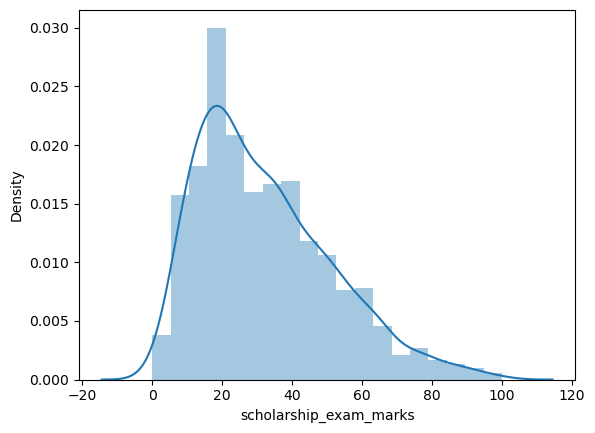

In [40]:
sns.distplot(data['scholarship_exam_marks'])

### we have seen that it is skewness the data 
### we can also visualize the outliers using boxplot

<Axes: ylabel='scholarship_exam_marks'>

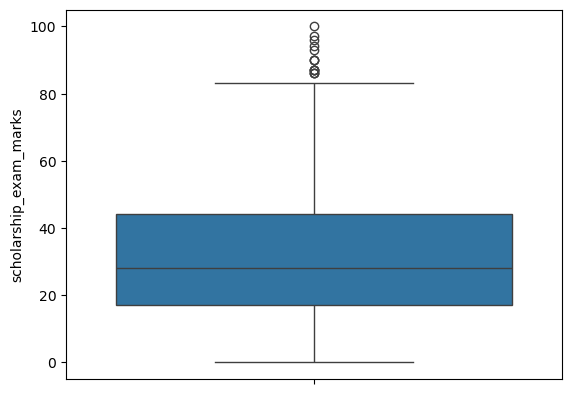

In [42]:
sns.boxplot(data['scholarship_exam_marks'])

## finding IQR

In [55]:
Q1 = data['scholarship_exam_marks'].quantile(0.25) #25% of data
Q3 = data['scholarship_exam_marks'].quantile(0.75) #75% of data
print("Q1=",Q1,"Q2=",Q3)
IQR = Q3 - Q1
print(IQR)
min = Q1-1.5*IQR
max = Q3+1.5*IQR
print("min = ",min,"max = ",max)

Q1= 17.0 Q2= 44.0
27.0
min =  -23.5 max =  84.5


### the values which are below the min and greater than max are outliers

In [56]:
data[(data['scholarship_exam_marks'] < min) | (data['scholarship_exam_marks'] >max)]

,semester_percentage,scholarship_exam_marks,got_scholarship
9,77.5,94,1
40,66.0,86,1
61,75.1,86,0
134,63.3,93,0
162,78.0,90,0
283,70.9,87,0
290,83.8,87,0
311,69.7,87,1
324,66.4,90,0
630,65.6,96,1


## trimmed data (with out outliers)

In [60]:
newdata=data[(data['scholarship_exam_marks'] > min) & (data['scholarship_exam_marks']<max)]
newdata

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26,1
1,74.6,38,1
2,75.4,40,1
3,64.2,8,1
4,72.3,17,0
...,...,...,...
995,88.7,44,1
996,91.2,65,1
997,48.9,34,0
998,86.2,46,1


## finding IQR using describe() function

In [51]:
data.describe()

,semester_percentage,scholarship_exam_marks,got_scholarship
count,1000.000000,1000.000000,1000.000000
mean,69.612400,32.225000,0.489000
std,6.158979,19.130822,0.500129
min,48.900000,0.000000,0.000000
25%,65.500000,17.000000,0.000000
50%,69.600000,28.000000,0.000000
75%,73.700000,44.000000,1.000000
max,91.200000,100.000000,1.000000


### to observe the difference between the data with outliers and without outliers

C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2364726872.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['scholarship_exam_marks'])
C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2364726872.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(newdata['scholarship_exam_marks'])


<Axes: ylabel='scholarship_exam_marks'>

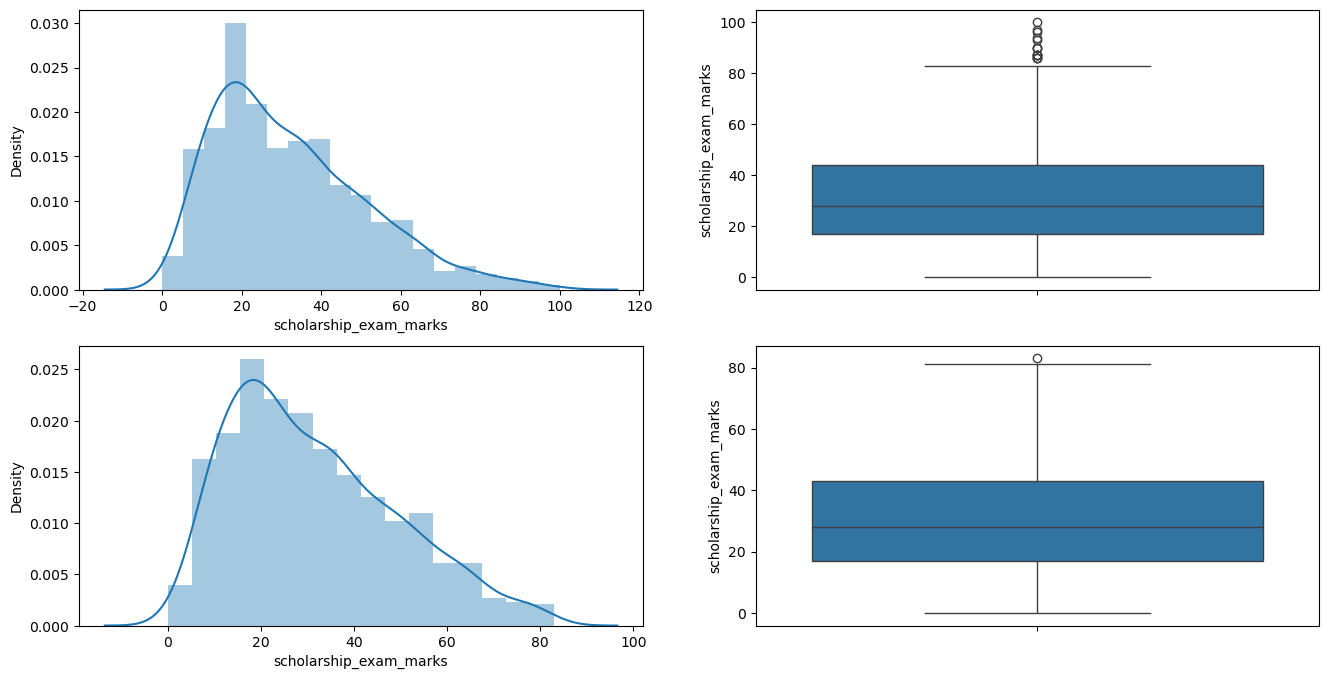

In [62]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['scholarship_exam_marks'])
plt.subplot(2,2,2)
sns.boxplot(df['scholarship_exam_marks'])
plt.subplot(2,2,3)
sns.distplot(newdata['scholarship_exam_marks'])
plt.subplot(2,2,4)
sns.boxplot(newdata['scholarship_exam_marks'])

## Capping on scholarship_exam_marks

In [64]:
data['scholarship_exam_marks'] = np.where(data['scholarship_exam_marks'] > max, max,
                                         np.where(data['scholarship_exam_marks']< min,min,data['scholarship_exam_marks']))

In [65]:
data

,semester_percentage,scholarship_exam_marks,got_scholarship
0,71.9,26.0,1
1,74.6,38.0,1
2,75.4,40.0,1
3,64.2,8.0,1
4,72.3,17.0,0
...,...,...,...
995,88.7,44.0,1
996,91.2,65.0,1
997,48.9,34.0,0
998,86.2,46.0,1


### we can observe after the capping we can see we replcaed the outliers without trimming

# OUTIERS WITH PERCENTILE

### decide percentile in both sides which you consider as outliers

In [66]:
dff = pd.read_csv('weight-height.csv')

In [67]:
dff.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


C:\Users\Raksh\AppData\Local\Temp\ipykernel_26228\2927237336.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dff['Height'])


<Axes: xlabel='Height', ylabel='Density'>

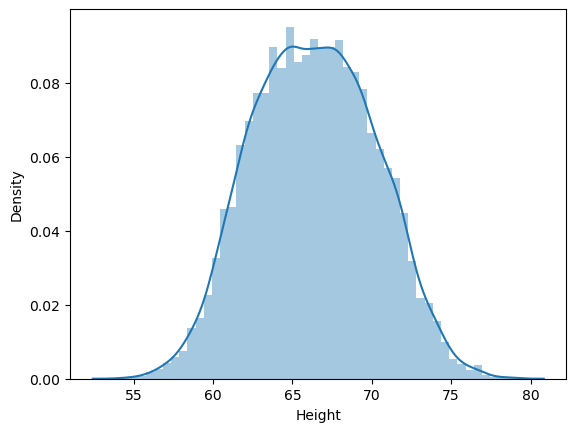

In [69]:
sns.distplot(dff['Height'])

### we can observe the gragh is similar to normal distribution but its not 
### it is neither Normal or skneweed 
### and we also see some outliers then we can use percentile method to handle outliers

<Axes: ylabel='Height'>

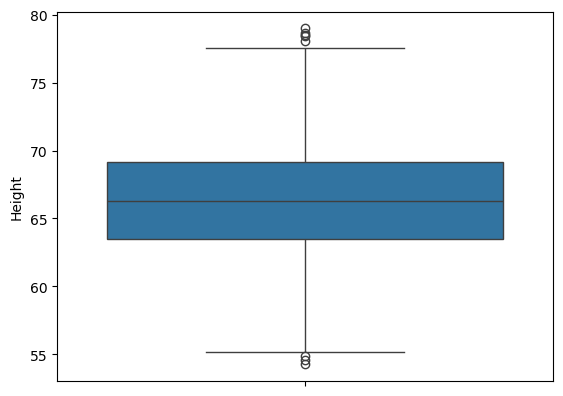

In [72]:
sns.boxplot(dff['Height'])

In [74]:
#we need to decide the percentile range of outliers
min_limit = dff["Height"].quantile(0.01) #values below the 1% are outliers
max_limit = dff["Height"].quantile(0.99) #values above the 99% are outliers

In [75]:
min_limit

np.float64(58.13441158671655)

In [76]:
max_limit

np.float64(74.7857900583366)

In [79]:
dff[(dff["Height"]>max_limit) | (dff["Height"] < min_limit)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [80]:
dff.shape

(10000, 3)

#### we had so many no. of outliers in dataset we can go for Capping rather than triming the data
## Capping

In [84]:
dff['Height'] = np.where(dff['Height']>max_limit,max_limit,
                        np.where(dff['Height']<min_limit, min_limit, dff['Height']))

In [85]:
dff['Height']

0       73.847017
1       68.781904
2       74.110105
3       71.730978
4       69.881796
          ...    
9995    66.172652
9996    67.067155
9997    63.867992
9998    69.034243
9999    61.944246
Name: Height, Length: 10000, dtype: float64

<Axes: ylabel='Height'>

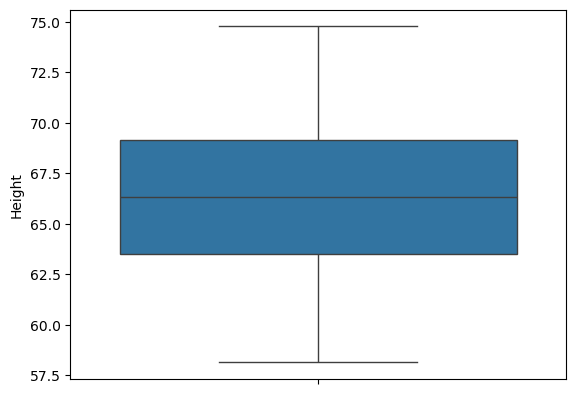

In [86]:
sns.boxplot(dff['Height'])  

### since we have capped there are no outliers